# Assignment Lab 6

## Part A - Image Feature Extraction and Classification

In [11]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
data_path = "./448/"

In [13]:
import os

print(os.path.exists(data_path))
print(os.listdir(data_path))

True
['Cracks', 'NonCracks']


In [14]:
crack_path = os.path.join(data_path, "Cracks")
non_crack_path = os.path.join(data_path, "NonCracks")

print("Crack images:", len(os.listdir(crack_path)))
print("Non-crack images:", len(os.listdir(non_crack_path)))

Crack images: 200
Non-crack images: 200


In [15]:
print("Total images:", len(os.listdir(crack_path)) + len(os.listdir(non_crack_path)))

Total images: 400


### Create image paths and labels

In [16]:
image_paths = []
labels = []

# Crack images
for file_name in os.listdir(crack_path):
    file_path = os.path.join(crack_path, file_name)
    image_paths.append(file_path)
    labels.append(1)

# Non-crack images
for file_name in os.listdir(non_crack_path):
    file_path = os.path.join(non_crack_path, file_name)
    image_paths.append(file_path)
    labels.append(0)

print("Total images:", len(image_paths))
print("Total labels:", len(labels))

Total images: 400
Total labels: 400


### Reading one image

In [17]:
img = cv2.imread(image_paths[0])

print("Image shape:", img.shape)
print("Image data type:", img.dtype)

Image shape: (448, 448, 3)
Image data type: uint8


### Displaying the image

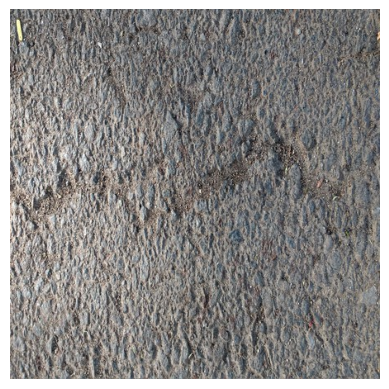

In [18]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis("off")
plt.show()

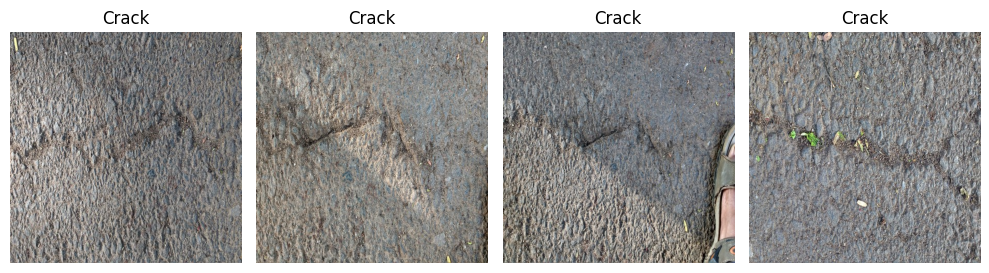

In [19]:
plt.figure(figsize=(10, 5))

for i in range(4):
    img = cv2.imread(image_paths[i])
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 4, i + 1)
    plt.imshow(img_rgb)
    plt.title("Crack" if labels[i] == 1 else "Non-crack")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Resize the image

In [20]:
IMG_SIZE = (128, 128)

resized = cv2.resize(img, IMG_SIZE)

print("Original shape:", img.shape)
print("Resized shape:", resized.shape)

Original shape: (448, 448, 3)
Resized shape: (128, 128, 3)


### Converting to grayscale

In [21]:
gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
print("Grayscale shape:", gray.shape)

Grayscale shape: (128, 128)


### Visualization the grayscale image


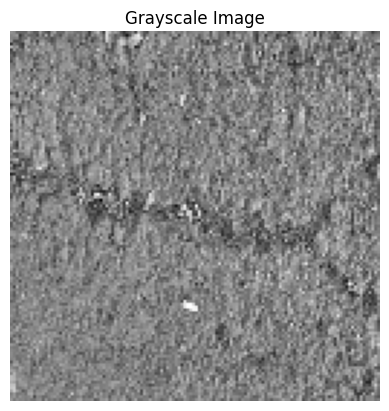

In [22]:
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

### Apply Canny edge detection

In [23]:
edges = cv2.Canny(gray, 100, 200)

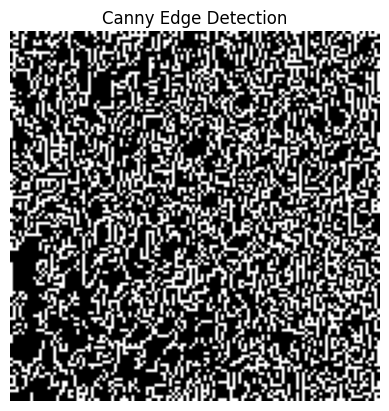

In [24]:
plt.imshow(edges, cmap="gray")
plt.title("Canny Edge Detection")
plt.axis("off")
plt.show()

### Extracting features from the current image

In [25]:
mean_brightness = np.mean(gray)
print("Mean brightness:", mean_brightness)

Mean brightness: 130.30914306640625


In [26]:
contrast = np.std(gray)
print("Contrast:", contrast)

Contrast: 27.28267642673459


### Dark-pixel ratio

In [27]:
dark_ratio = np.mean(gray < 50)
print("Dark pixel ratio:", dark_ratio)

Dark pixel ratio: 0.002197265625


### Bright-pixel ratio

In [28]:
bright_ratio = np.mean(gray > 200)
print("Bright pixel ratio:", bright_ratio)

Bright pixel ratio: 0.006591796875


### Edge Count

In [29]:
edges = cv2.Canny(gray, 100, 200)

In [30]:
edge_count = np.sum(edges > 0)
print("Edge count:", edge_count)

Edge count: 5507


### Edge Density

In [31]:
edge_density = edge_count / edges.size
print("Edge density:", edge_density)

Edge density: 0.33612060546875


In [32]:
print("Mean brightness:", mean_brightness)
print("Contrast:", contrast)
print("Dark ratio:", dark_ratio)
print("Bright ratio:", bright_ratio)
print("Edge count:", edge_count)
print("Edge density:", edge_density)

Mean brightness: 130.30914306640625
Contrast: 27.28267642673459
Dark ratio: 0.002197265625
Bright ratio: 0.006591796875
Edge count: 5507
Edge density: 0.33612060546875


### Extract above features for all 400 images

In [33]:
all_features = []

for image_path, label in zip(image_paths, labels):

    # Read image
    img = cv2.imread(image_path)

    # Resize
    resized = cv2.resize(img, IMG_SIZE)

    # Convert to grayscale
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

    # Intensity features
    mean_brightness = np.mean(gray)
    contrast = np.std(gray)
    dark_ratio = np.mean(gray < 50)
    bright_ratio = np.mean(gray > 200)

    # Canny edges
    edges = cv2.Canny(gray, 100, 200)

    # Edge features
    edge_count = np.sum(edges > 0)
    edge_density = edge_count / edges.size

    # Store features
    row = {
        "image": os.path.basename(image_path),
        "mean_brightness": mean_brightness,
        "contrast": contrast,
        "dark_ratio": dark_ratio,
        "bright_ratio": bright_ratio,
        "edge_count": edge_count,
        "edge_density": edge_density,
        "label": label
    }

    all_features.append(row)

In [34]:
image_features = pd.DataFrame(all_features)

print("Feature table shape:", image_features.shape)

Feature table shape: (400, 8)


In [35]:
image_features.head()

,image,mean_brightness,contrast,dark_ratio,bright_ratio,edge_count,edge_density,label
0,IMG_20180513_164959951_HDR resized_448.jpg,122.263977,33.070752,0.005859,0.014465,5580,0.340576,1
1,IMG_20180513_165129852_HDR resized_448.jpg,131.565186,25.482184,0.003418,0.004456,4579,0.279480,1
2,IMG_20180513_165150613_HDR resized_448.jpg,121.076355,31.130490,0.014221,0.010498,4303,0.262634,1
3,IMG_20180513_165345878_HDR resized_448.jpg,130.309143,27.282676,0.002197,0.006592,5507,0.336121,1
4,IMG_20180513_165349788_HDR resized_448.jpg,130.993286,27.639562,0.003357,0.007751,5218,0.318481,1


In [36]:
image_features.describe()

,mean_brightness,contrast,dark_ratio,bright_ratio,edge_count,edge_density,label
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,150.824035,27.827543,0.004825,0.061163,4449.130000,0.271553,0.500000
std,17.758345,8.449777,0.012947,0.055335,1716.830455,0.104787,0.500626
min,110.385376,15.257929,0.000000,0.000366,635.000000,0.038757,0.000000
25%,134.273758,20.027965,0.000000,0.015167,3055.250000,0.186478,0.000000
50%,152.684937,27.593828,0.000122,0.049133,5311.500000,0.324188,0.500000
75%,165.949829,33.679349,0.003540,0.088394,5793.750000,0.353622,1.000000
max,189.577637,56.364362,0.134705,0.280334,6334.000000,0.386597,1.000000


In [37]:
print(image_features["label"].value_counts())

label
1    200
0    200
Name: count, dtype: int64


In [38]:
image_features.to_csv("image_features.csv", index=False)

In [39]:
print("Saved image_features.csv")

Saved image_features.csv


In [40]:
print(image_features.shape)
image_features.head()

(400, 8)


,image,mean_brightness,contrast,dark_ratio,bright_ratio,edge_count,edge_density,label
0,IMG_20180513_164959951_HDR resized_448.jpg,122.263977,33.070752,0.005859,0.014465,5580,0.340576,1
1,IMG_20180513_165129852_HDR resized_448.jpg,131.565186,25.482184,0.003418,0.004456,4579,0.279480,1
2,IMG_20180513_165150613_HDR resized_448.jpg,121.076355,31.130490,0.014221,0.010498,4303,0.262634,1
3,IMG_20180513_165345878_HDR resized_448.jpg,130.309143,27.282676,0.002197,0.006592,5507,0.336121,1
4,IMG_20180513_165349788_HDR resized_448.jpg,130.993286,27.639562,0.003357,0.007751,5218,0.318481,1


### Separate features and target

In [41]:
X = image_features.drop(columns=["image", "label"])
y = image_features["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (400, 6)
y shape: (400,)


### Train-test split

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 320
Testing samples: 80


### Train a Logistic Regression model

In [43]:
from sklearn.linear_model import LogisticRegression
import time

model = LogisticRegression(max_iter=1000)

start_time = time.time()

model.fit(X_train, y_train)

train_time = time.time() - start_time

print("Training time:", train_time, "seconds")

Training time: 0.14293217658996582 seconds


In [44]:
start_time = time.time()

y_pred = model.predict(X_test)

prediction_time = time.time() - start_time

print("Prediction time:", prediction_time, "seconds")

Prediction time: 0.006035804748535156 seconds


### Calculate evaluation metrics

In [45]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

Accuracy : 0.625
Precision: 0.6041666666666666
Recall   : 0.725
F1-score : 0.6590909090909091


### Confusion matrix

In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[21 19]
 [11 29]]


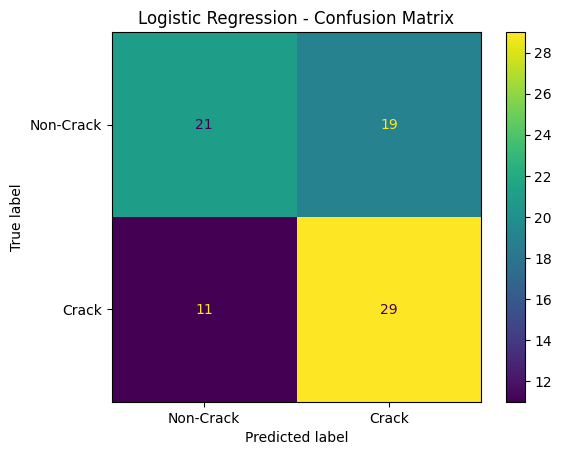

In [47]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Crack", "Crack"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [48]:
image_results = []

image_results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "Training Time": train_time,
    "Prediction Time": prediction_time
})

In [49]:
pd.DataFrame(image_results)

,Model,Accuracy,Precision,Recall,F1,Training Time,Prediction Time
0,Logistic Regression,0.625,0.604167,0.725,0.659091,0.142932,0.006036


### Random Forest

In [50]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

start_time = time.time()

rf_model.fit(X_train, y_train)

rf_train_time = time.time() - start_time

In [51]:
start_time = time.time()

rf_pred = rf_model.predict(X_test)

rf_prediction_time = time.time() - start_time

In [52]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-score : {rf_f1:.4f}")
print(f"Training time: {rf_train_time:.6f} seconds")
print(f"Prediction time: {rf_prediction_time:.6f} seconds")

Accuracy : 0.9375
Precision: 0.9487
Recall   : 0.9250
F1-score : 0.9367
Training time: 0.414367 seconds
Prediction time: 0.040047 seconds


In [53]:
image_results.append({
    "Model": "Random Forest",
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1": rf_f1,
    "Training Time": rf_train_time,
    "Prediction Time": rf_prediction_time
})

In [54]:
image_results_df = pd.DataFrame(image_results)
image_results_df

,Model,Accuracy,Precision,Recall,F1,Training Time,Prediction Time
0,Logistic Regression,0.6250,0.604167,0.725,0.659091,0.142932,0.006036
1,Random Forest,0.9375,0.948718,0.925,0.936709,0.414367,0.040047


### Confusion matrix for Random Forest

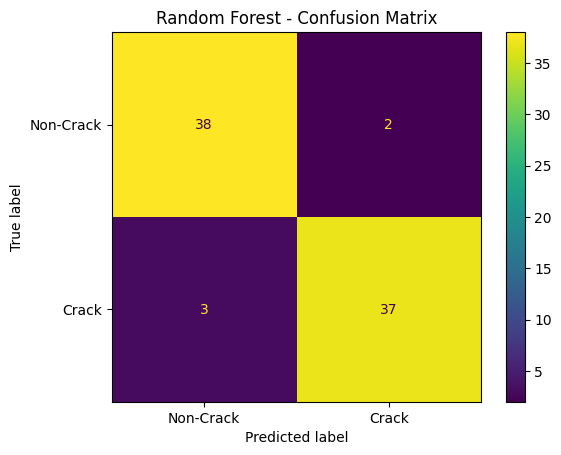

In [55]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Crack", "Crack"]
)

disp.plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

In [56]:
image_results_df = image_results_df.round(4)

image_results_df

,Model,Accuracy,Precision,Recall,F1,Training Time,Prediction Time
0,Logistic Regression,0.6250,0.6042,0.725,0.6591,0.1429,0.006
1,Random Forest,0.9375,0.9487,0.925,0.9367,0.4144,0.040


In [57]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Train scaled Logistic Regression

In [58]:
scaled_model = LogisticRegression(max_iter=1000)

start_time = time.time()

scaled_model.fit(X_train_scaled, y_train)

scaled_train_time = time.time() - start_time

In [59]:
start_time = time.time()

scaled_pred = scaled_model.predict(X_test_scaled)

scaled_prediction_time = time.time() - start_time

In [60]:
scaled_accuracy = accuracy_score(y_test, scaled_pred)
scaled_precision = precision_score(y_test, scaled_pred)
scaled_recall = recall_score(y_test, scaled_pred)
scaled_f1 = f1_score(y_test, scaled_pred)

print("Accuracy:", scaled_accuracy)
print("Precision:", scaled_precision)
print("Recall:", scaled_recall)
print("F1:", scaled_f1)
print("Training Time:", scaled_train_time)
print("Prediction Time:", scaled_prediction_time)

Accuracy: 0.925
Precision: 0.925
Recall: 0.925
F1: 0.925
Training Time: 0.01759505271911621
Prediction Time: 0.0009748935699462891


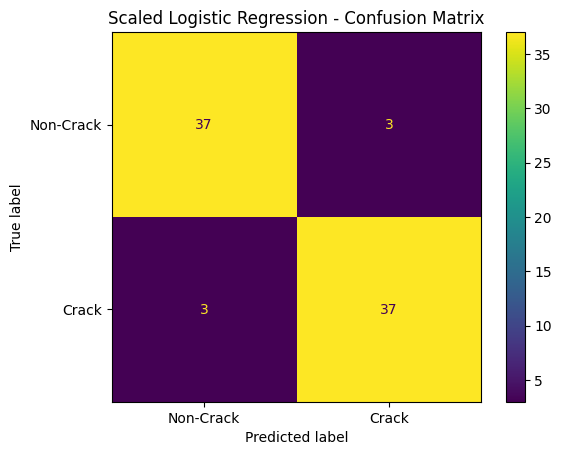

In [61]:
cm = confusion_matrix(y_test, scaled_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Crack", "Crack"]
)

disp.plot()
plt.title("Scaled Logistic Regression - Confusion Matrix")
plt.show()

## Part A: Observation

The image features were extracted using grayscale intensity statistics and Canny edge information. Logistic Regression initially achieved 62.50% accuracy. After applying StandardScaler, its accuracy increased to 92.50%, showing that feature scaling was important for this model.

Random Forest achieved 93.75% accuracy, with a precision of 94.87%, recall of 92.50%, and F1-score of 93.67%. Its confusion matrix shows that it correctly classified 75 out of 80 test images.

Overall, scaling substantially improved Logistic Regression, while Random Forest provided strong performance using the extracted image features.

## Part B - Text Vectorization and Spam Classification

In [62]:
import pandas as pd

df = pd.read_csv("./emails.csv/emails.csv")

print("Shape:", df.shape)
df.head()

Shape: (5172, 3002)


,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0


In [63]:
print(df.columns)

Index(['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou',
       ...
       'connevey', 'jay', 'valued', 'lay', 'infrastructure', 'military',
       'allowing', 'ff', 'dry', 'Prediction'],
      dtype='str', length=3002)


In [64]:
df.isnull().sum()

Email No.     0
the           0
to            0
ect           0
and           0
             ..
military      0
allowing      0
ff            0
dry           0
Prediction    0
Length: 3002, dtype: int64

In [65]:
print("Shape:", df.shape)

Shape: (5172, 3002)


In [66]:
print(df.columns[:15])
print(df.columns[-10:])

Index(['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou',
       'in', 'on', 'is', 'this', 'enron'],
      dtype='str')
Index(['connevey', 'jay', 'valued', 'lay', 'infrastructure', 'military',
       'allowing', 'ff', 'dry', 'Prediction'],
      dtype='str')


In [67]:
print(df["Prediction"].value_counts())

Prediction
0    3672
1    1500
Name: count, dtype: int64


### Preparing the data

In [68]:
X = df.drop(columns=["Email No.", "Prediction"])
y = df["Prediction"]

In [69]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5172, 3000)
y shape: (5172,)


In [70]:
X.dtypes.value_counts()

int64    3000
Name: count, dtype: int64

In [71]:
X.head()

,the,to,ect,and,for,of,a,you,hou,in,...,enhancements,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry
0,0,0,1,0,0,0,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,8,13,24,6,6,2,102,1,27,18,...,0,0,0,0,0,0,0,0,1,0
2,0,0,1,0,0,0,8,0,0,4,...,0,0,0,0,0,0,0,0,0,0
3,0,5,22,0,5,1,51,2,10,1,...,0,0,0,0,0,0,0,0,0,0
4,7,6,17,1,5,2,57,0,9,3,...,0,0,0,0,0,0,0,0,1,0


In [72]:
X.describe().loc[["min", "max", "mean"]].T.head(10)

,min,max,mean
the,0.0,210.0,6.640565
to,0.0,132.0,6.188128
ect,1.0,344.0,5.143852
and,0.0,89.0,3.075599
for,0.0,47.0,3.124710
of,0.0,77.0,2.627030
a,0.0,1898.0,55.517401
you,0.0,70.0,2.466551
hou,0.0,167.0,2.024362
in,0.0,223.0,10.600155


### Train/test split

In [73]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 4137
Testing samples: 1035


### Multinomial Naive Bayes

In [74]:
from sklearn.naive_bayes import MultinomialNB
import time

nb_model = MultinomialNB()

start_time = time.time()

nb_model.fit(X_train, y_train)

nb_train_time = time.time() - start_time

start_time = time.time()

nb_pred = nb_model.predict(X_test)

nb_prediction_time = time.time() - start_time

### Calculate Evaluation Metrics

In [75]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

nb_accuracy = accuracy_score(y_test, nb_pred)
nb_precision = precision_score(y_test, nb_pred)
nb_recall = recall_score(y_test, nb_pred)
nb_f1 = f1_score(y_test, nb_pred)

print("Accuracy :", nb_accuracy)
print("Precision:", nb_precision)
print("Recall   :", nb_recall)
print("F1-score :", nb_f1)
print("Training time:", nb_train_time)
print("Prediction time:", nb_prediction_time)

Accuracy : 0.9420289855072463
Precision: 0.8680981595092024
Recall   : 0.9433333333333334
F1-score : 0.9041533546325878
Training time: 0.21798419952392578
Prediction time: 0.13827013969421387


### Confusion Matrix for Multinominal Naive Bayes

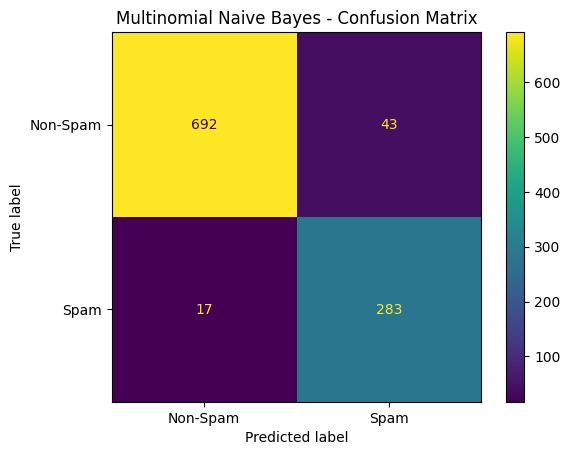

In [76]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, nb_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Spam", "Spam"]
)

disp.plot()
plt.title("Multinomial Naive Bayes - Confusion Matrix")
plt.show()

### Logistic Regression

In [77]:
from sklearn.linear_model import LogisticRegression

lr_text_model = LogisticRegression(max_iter=1000)

start_time = time.time()

lr_text_model.fit(X_train, y_train)

lr_text_train_time = time.time() - start_time

start_time = time.time()

lr_text_pred = lr_text_model.predict(X_test)

lr_text_prediction_time = time.time() - start_time

### Calculate Evaluation Metrics

In [78]:
lr_text_accuracy = accuracy_score(y_test, lr_text_pred)
lr_text_precision = precision_score(y_test, lr_text_pred)
lr_text_recall = recall_score(y_test, lr_text_pred)
lr_text_f1 = f1_score(y_test, lr_text_pred)

print("Accuracy :", lr_text_accuracy)
print("Precision:", lr_text_precision)
print("Recall   :", lr_text_recall)
print("F1-score :", lr_text_f1)
print("Training time:", lr_text_train_time)
print("Prediction time:", lr_text_prediction_time)

Accuracy : 0.9826086956521739
Precision: 0.9577922077922078
Recall   : 0.9833333333333333
F1-score : 0.9703947368421053
Training time: 9.974215269088745
Prediction time: 0.09906673431396484


### Confusion Matrix for Logistic Regression 

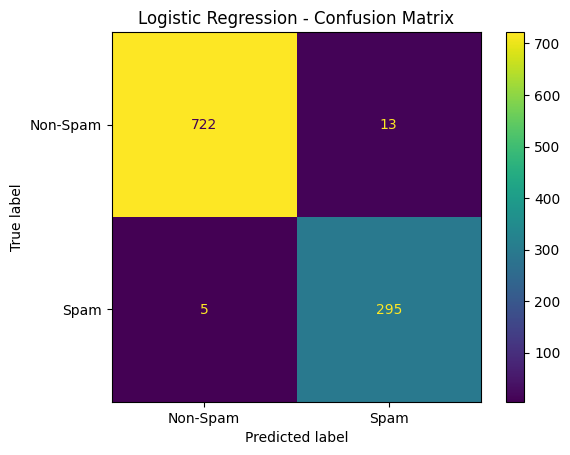

In [79]:
cm = confusion_matrix(y_test, lr_text_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Spam", "Spam"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [80]:
text_results = pd.DataFrame([
    {
        "Model": "Multinomial Naive Bayes",
        "Accuracy": nb_accuracy,
        "Precision": nb_precision,
        "Recall": nb_recall,
        "F1": nb_f1,
        "Training Time": nb_train_time,
        "Prediction Time": nb_prediction_time
    },
    {
        "Model": "Logistic Regression",
        "Accuracy": lr_text_accuracy,
        "Precision": lr_text_precision,
        "Recall": lr_text_recall,
        "F1": lr_text_f1,
        "Training Time": lr_text_train_time,
        "Prediction Time": lr_text_prediction_time
    }
])

text_results.round(4)

,Model,Accuracy,Precision,Recall,F1,Training Time,Prediction Time
0,Multinomial Naive Bayes,0.9420,0.8681,0.9433,0.9042,0.2180,0.1383
1,Logistic Regression,0.9826,0.9578,0.9833,0.9704,9.9742,0.0991


## Part B: Observation

The provided email dataset already contains 3000 word-frequency features for each email, so it was used directly as a bag-of-words representation rather than applying CountVectorizer again.

Multinomial Naive Bayes achieved 94.20% accuracy, while Logistic Regression achieved 98.26% accuracy on the same test set. Logistic Regression also achieved higher precision, recall, and F1-score, although it required more training time.

The results show that Logistic Regression performed better on the given word-frequency representation, while Multinomial Naive Bayes required less training time.

## Part C - Improve the Representation

### Select informative features

In [81]:
from sklearn.feature_selection import SelectKBest, chi2

selector = SelectKBest(score_func=chi2, k=1000)

X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

print("Original features:", X_train.shape[1])
print("Selected features:", X_train_selected.shape[1])

Original features: 3000
Selected features: 1000


In [82]:
selector.fit_transform(X_train, y_train)

array([[ 1,  1,  2, ...,  0,  0,  0],
       [ 0,  2,  1, ...,  0,  0,  1],
       [ 2,  1,  0, ...,  0,  0,  0],
       ...,
       [ 6,  3,  0, ...,  0,  0,  2],
       [ 5,  4,  4, ...,  0,  0,  0],
       [12,  5,  6, ...,  0,  0,  0]], shape=(4137, 1000))

In [83]:
selector.transform(X_test)

array([[2, 3, 0, ..., 0, 0, 1],
       [5, 4, 5, ..., 0, 0, 1],
       [3, 1, 0, ..., 0, 0, 0],
       ...,
       [2, 1, 0, ..., 0, 0, 2],
       [4, 2, 0, ..., 0, 0, 1],
       [2, 2, 1, ..., 0, 0, 0]], shape=(1035, 1000))

### Train Logistic Regression on selected features

In [84]:
improved_model = LogisticRegression(max_iter=1000)

start_time = time.time()

improved_model.fit(X_train_selected, y_train)

improved_train_time = time.time() - start_time

start_time = time.time()

improved_pred = improved_model.predict(X_test_selected)

improved_prediction_time = time.time() - start_time

### Calculate Evaluation Metrics

In [85]:
improved_accuracy = accuracy_score(y_test, improved_pred)
improved_precision = precision_score(y_test, improved_pred)
improved_recall = recall_score(y_test, improved_pred)
improved_f1 = f1_score(y_test, improved_pred)

print("Accuracy :", improved_accuracy)
print("Precision:", improved_precision)
print("Recall   :", improved_recall)
print("F1-score :", improved_f1)
print("Training time:", improved_train_time)
print("Prediction time:", improved_prediction_time)

Accuracy : 0.9729468599033816
Precision: 0.9473684210526315
Recall   : 0.96
F1-score : 0.9536423841059603
Training time: 8.097538232803345
Prediction time: 0.010867834091186523


### Add histogram features

In [86]:
import cv2
import numpy as np
import os
import pandas as pd

improved_image_features = []

for image_path, label in zip(image_paths, labels):

    img = cv2.imread(image_path)
    resized = cv2.resize(img, IMG_SIZE)
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

    # Existing features
    mean_brightness = np.mean(gray)
    contrast = np.std(gray)

    dark_ratio = np.mean(gray < 50)
    bright_ratio = np.mean(gray > 200)

    edges = cv2.Canny(gray, 100, 200)

    edge_count = np.sum(edges > 0)
    edge_density = edge_count / edges.size

    # New: grayscale histogram
    hist = cv2.calcHist(
        [gray],
        [0],
        None,
        [16],
        [0, 256]
    )

    # Normalize histogram
    hist = hist.flatten()
    hist = hist / hist.sum()

    row = {
        "image": os.path.basename(image_path),
        "mean_brightness": mean_brightness,
        "contrast": contrast,
        "dark_ratio": dark_ratio,
        "bright_ratio": bright_ratio,
        "edge_count": edge_count,
        "edge_density": edge_density,
        "label": label
    }

    # Add 16 histogram features
    for i in range(16):
        row[f"hist_{i}"] = hist[i]

    improved_image_features.append(row)

improved_image_df = pd.DataFrame(improved_image_features)

print(improved_image_df.shape)
improved_image_df.head()

(400, 24)


,image,mean_brightness,contrast,dark_ratio,bright_ratio,edge_count,edge_density,label,hist_0,hist_1,...,hist_6,hist_7,hist_8,hist_9,hist_10,hist_11,hist_12,hist_13,hist_14,hist_15
0,IMG_20180513_164959951_HDR resized_448.jpg,122.263977,33.070752,0.005859,0.014465,5580,0.340576,1,0.000000,0.000183,...,0.176086,0.186890,0.164551,0.120911,0.070984,0.038391,0.017822,0.006165,0.001160,0.000244
1,IMG_20180513_165129852_HDR resized_448.jpg,131.565186,25.482184,0.003418,0.004456,4579,0.279480,1,0.000183,0.000732,...,0.116394,0.212891,0.270874,0.207520,0.073914,0.027283,0.008362,0.001953,0.000183,0.000183
2,IMG_20180513_165150613_HDR resized_448.jpg,121.076355,31.130490,0.014221,0.010498,4303,0.262634,1,0.001038,0.003296,...,0.179993,0.262085,0.185181,0.085510,0.054260,0.033569,0.016541,0.004456,0.000671,0.000000
3,IMG_20180513_165345878_HDR resized_448.jpg,130.309143,27.282676,0.002197,0.006592,5507,0.336121,1,0.000061,0.000122,...,0.139160,0.201111,0.235474,0.190430,0.088867,0.029297,0.008057,0.002502,0.000793,0.000610
4,IMG_20180513_165349788_HDR resized_448.jpg,130.993286,27.639562,0.003357,0.007751,5218,0.318481,1,0.000000,0.000427,...,0.130737,0.201904,0.245789,0.187073,0.091675,0.030945,0.008911,0.002625,0.001343,0.001160


### Improved image features

In [87]:
X_improved = improved_image_df.drop(columns=["image", "label"])
y_improved = improved_image_df["label"]

In [88]:
X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(
    X_improved,
    y_improved,
    test_size=0.20,
    random_state=42,
    stratify=y_improved
)

print("Training samples:", X_train_imp.shape[0])
print("Testing samples:", X_test_imp.shape[0])

Training samples: 320
Testing samples: 80


### Train Random Forest

In [89]:
improved_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

start_time = time.time()

improved_rf.fit(X_train_imp, y_train_imp)

improved_rf_train_time = time.time() - start_time

In [90]:
start_time = time.time()

improved_rf_pred = improved_rf.predict(X_test_imp)

improved_rf_prediction_time = time.time() - start_time

### Calculate Evaluation Metrics

In [91]:
improved_rf_accuracy = accuracy_score(y_test_imp, improved_rf_pred)
improved_rf_precision = precision_score(y_test_imp, improved_rf_pred)
improved_rf_recall = recall_score(y_test_imp, improved_rf_pred)
improved_rf_f1 = f1_score(y_test_imp, improved_rf_pred)

print("Accuracy :", improved_rf_accuracy)
print("Precision:", improved_rf_precision)
print("Recall   :", improved_rf_recall)
print("F1-score :", improved_rf_f1)
print("Training time:", improved_rf_train_time)
print("Prediction time:", improved_rf_prediction_time)

Accuracy : 0.9625
Precision: 0.9512195121951219
Recall   : 0.975
F1-score : 0.9629629629629629
Training time: 0.38236236572265625
Prediction time: 0.03809762001037598


### Improved Random Forest confusion matrix

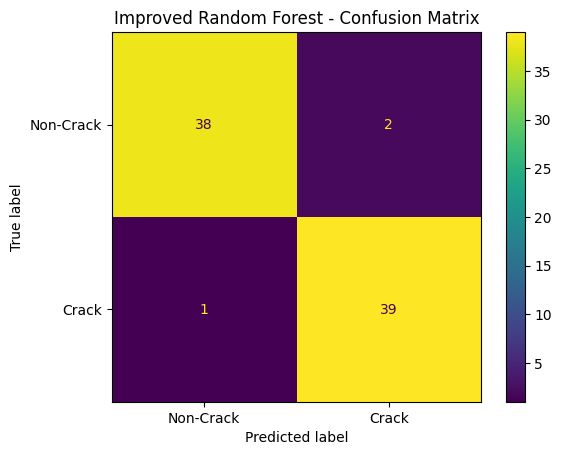

In [92]:
cm = confusion_matrix(y_test_imp, improved_rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Crack", "Crack"]
)

disp.plot()
plt.title("Improved Random Forest - Confusion Matrix")
plt.show()

## Part C: Observation

To improve the image representation, 16 normalized grayscale histogram features were added to the original six image features. This increased the numerical feature set from 6 to 22 features.

The improved Random Forest achieved 96.25% accuracy and an F1-score of 96.30%, compared with 93.75% accuracy and 93.67% F1-score for the original Random Forest.

The improved model correctly classified 77 out of 80 test images, with only 3 misclassifications. This indicates that the additional histogram features provided useful information for distinguishing crack and non-crack images.